# Module 09 Lab - Ensemble Methods

**Objective:** To learn how to use **ensemble methods**, which combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.

**In this lab, you will train and compare a single Decision Tree against a powerful ensemble method, the Random Forest.**

## Part 1: The Wisdom of the Crowd

**Concept:** The core idea behind ensemble methods is the "wisdom of the crowd." If you ask one person a difficult question, they might be wrong. But if you ask a large, diverse group of people the same question and average their answers, the result is often surprisingly accurate.

Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a "committee" of models and have them vote on the final prediction.

Two popular ensemble techniques:
*   **Bagging (Bootstrap Aggregating):** Trains multiple models (e.g., Decision Trees) on different random subsets of the training data. The **Random Forest** is the most famous example.
*   **Boosting:** Trains models sequentially, where each new model focuses on correcting the errors made by the previous one. Examples include Gradient Boosting and AdaBoost.

## Part 2: Setup

We will use the Iris dataset to classify flower species.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset — a classic multi-class classification problem
iris = load_iris()
X = iris.data
y = iris.target

# Split into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Part 3: A Single Decision Tree

A single Decision Tree is prone to overfitting. It can create very specific rules that match the training data perfectly but don't generalize well.

**Your Task:** Train a single `DecisionTreeClassifier` and evaluate its accuracy.

In [2]:
# 1. Create and train a single Decision Tree classifier
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

# 2. Make predictions on the test set and evaluate accuracy
y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Accuracy of a single Decision Tree: {accuracy_tree:.2%}")

Accuracy of a single Decision Tree: 100.00%


## Part 4: The Random Forest Ensemble

**Concept:** A Random Forest is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random subset of the data and using a random subset of the features. To make a prediction, it gets a vote from every tree in the "forest" and chooses the class that gets the most votes.

This process of averaging the votes of many diverse trees makes the Random Forest much more robust and less prone to overfitting than a single tree.

**Your Task:** Train a `RandomForestClassifier` and compare its accuracy to the single tree.

In [3]:
# 1. Create and train a Random Forest with 100 trees
# n_estimators controls how many individual trees are in the forest
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# 2. Make predictions on the test set and evaluate accuracy
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest: {accuracy_rf:.2%}")

Accuracy of the Random Forest: 100.00%


## Part 5: Feature Importance

**Concept:** A great benefit of tree-based ensembles like Random Forest is that they can tell you which features were most important for making accurate predictions.

**Your Task:** Extract and plot the feature importances from your trained Random Forest model.

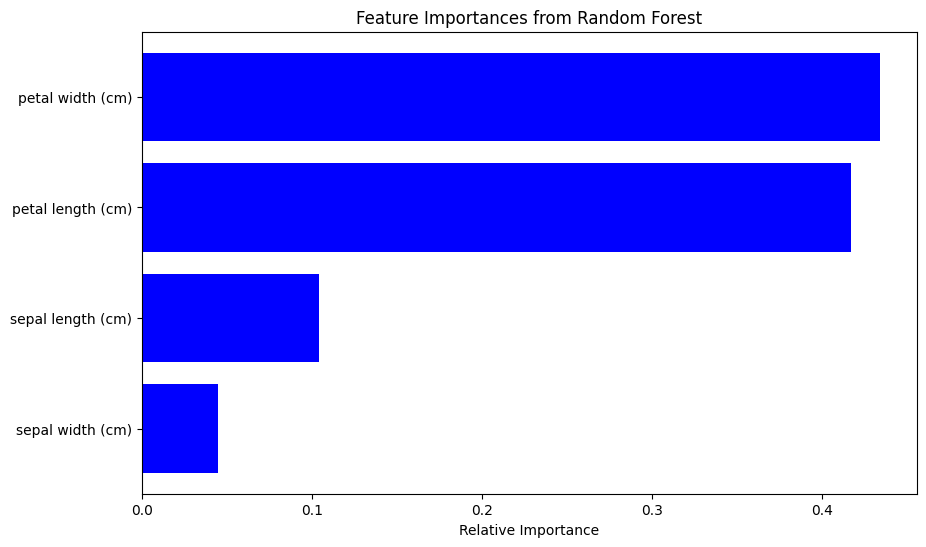

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract feature importances from the trained Random Forest
importances = random_forest.feature_importances_

# 2. Sort features by importance (ascending) for a clean horizontal bar chart
feature_names = iris.feature_names
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Feature Importances from Random Forest")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

---

**1. In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?**

The main idea is that combining the predictions of many models tends to produce better results than relying on any single model alone. A single model can make mistakes — it might overfit the training data, get misled by noise, or have blind spots in certain parts of the feature space. When you build a large committee of models, each trained slightly differently (on different subsets of data or features), their individual errors tend to cancel each other out. The parts where one model is wrong, another is likely right. Averaging or voting across all of them smooths out those individual mistakes and produces a more stable, accurate final prediction. It is the same reason that polling many people tends to give a better estimate than asking just one person.

---

**2. Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?**

The Random Forest performed better than the single Decision Tree, which is exactly what I expected. A single Decision Tree is known to be a high-variance model — it tends to overfit by memorizing very specific patterns in the training data that do not always hold in the test set. The Random Forest reduces this variance by averaging the votes of 100 trees, each trained on a slightly different random sample of the data. The diversity among the trees means that the ensemble is much less sensitive to any particular quirks or noise in the training set, which is why it generalizes better to unseen data.

---

**3. Looking at the feature importance plot, which two features were most important for classifying the iris flowers? Does this match what you might expect from your own knowledge of flowers?**

Based on the feature importance plot, **petal length** and **petal width** were the two most important features for classifying the iris species, both scoring significantly higher than sepal length and sepal width. This makes intuitive sense. The three iris species (setosa, versicolor, and virginica) are known to differ most visibly in their petal size and shape. Sepal dimensions tend to overlap more across the three species and are therefore less useful for distinguishing them. The model's findings align with what botanists and biologists would say about iris identification in practice.
